In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gzip # open gzip file
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader

In [82]:
def read_labels_from_file(filename):
    # open the provided file with gzip
    with gzip.open(filename, 'rb') as f:
        # Read the first byte which should be the magic number
        magic = f.read(4)
        magic = int.from_bytes(magic, 'big')
        print("The Magic number is:", magic)

        # Read the next byte which will be the number of labels
        nolab = f.read(4)
        nolab = int.from_bytes(nolab, 'big')
        print("Number of labels:", nolab)
        # Fill the labels list with bytes and then parse the bytes
        labels = [f.read(1) for i in range(nolab)]
        labels = [int.from_bytes(label, 'big') for label in labels]

    return labels

In [83]:
def read_images_from_file(filename):
    with gzip.open(filename, 'rb') as f:
        magic = f.read(4)
        magic = int.from_bytes(magic, 'big')
        print("Magic is: ", magic)

        noimg = f.read(4)
        noimg = int.from_bytes(noimg, 'big')
        print("Number of images: ", noimg)

        nocol = f.read(4) # Read the next 4 bytes to get the number of columns.
        nocol = int.from_bytes(nocol, 'big')
        print("Number of column: ", nocol)

        # Read the next 4 bytes to get the number of rows.
        norow = f.read(4)
        norow = int.from_bytes(norow, 'big')
        print("Number of labels: ", norow)

        images = [] # Image the [] represents an array
        # Loop through all images
        for i in range(noimg):
            row = []
            for r in range(norow):
                cols = []
                for c in range(nocol):
                    cols.append(int.from_bytes(f.read(1), 'big'))
                row.append(cols)
            images.append(row)

        return images

In [84]:
train_labels = read_labels_from_file("data/train-labels-idx1-ubyte.gz")
train_images = read_images_from_file("data/train-images-idx3-ubyte.gz")

test_labels = read_labels_from_file("data/t10k-labels-idx1-ubyte.gz")
test_images = read_images_from_file("data/t10k-images-idx3-ubyte.gz")

The Magic number is: 2049
Number of labels: 60000
Magic is:  2051
Number of images:  60000
Number of column:  28
Number of labels:  28
The Magic number is: 2049
Number of labels: 10000
Magic is:  2051
Number of images:  10000
Number of column:  28
Number of labels:  28


In [85]:
def plot_confusion_matrix(y_true, y_pred, classes):
    """Построение и визуализация матрицы ковариаций"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [86]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = np.array(images, dtype=np.float32).reshape(-1, 1, 28, 28) / 255.0
        self.labels = np.array(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image)

        return image, label

In [87]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # Сверточные слои
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)  # 28x28x1 -> 28x28x6
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)  # 28x28x6 -> 14x14x6
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)  # 14x14x6 -> 10x10x16
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)  # 10x10x16 -> 5x5x16

        # Полносвязные слои
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Проход через сверточные слои
        x = F.tanh(self.conv1(x))
        x = self.pool1(x)
        x = F.tanh(self.conv2(x))
        x = self.pool2(x)

        # Разворачиваем тензор для полносвязных слоев
        x = x.view(-1, 5*5*16)

        # Проход через полносвязные слои
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

In [88]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

In [89]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_targets = []
    wrong_samples = []  # Будем сохранять примеры ошибок

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1)  # Убрали keepdim=True

            correct += pred.eq(target).sum().item()

            # Сохраняем предсказания и истинные метки
            all_preds.extend(pred.cpu().numpy().flatten())  # Преобразуем в плоский массив
            all_targets.extend(target.cpu().numpy().flatten())

            # Сохраняем примеры ошибок (данные, истинная метка, предсказание)
            wrong_mask = ~pred.eq(target)
            wrong_samples.extend(zip(data[wrong_mask].cpu(),
                                target[wrong_mask].cpu().numpy(),
                                pred[wrong_mask].cpu().numpy()))

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, '
          f'Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({100. * correct / len(test_loader.dataset):.0f}%)\n')

    # Построение матрицы ковариаций
    plot_confusion_matrix(all_targets, all_preds, classes=[str(i) for i in range(10)])

    # Вывод примеров ошибок
    print("\nПримеры ошибок классификации:")
    plt.figure(figsize=(15, 10))
    for i, (img, true_label, pred_label) in enumerate(wrong_samples[:5]):
        plt.subplot(1, 5, i+1)
        img = img.squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {true_label}\nPred: {pred_label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Вывод распределения ошибок
    error_counts = {}
    for true, pred in zip(all_targets, all_preds):
        if true != pred:
            error_counts[(true, pred)] = error_counts.get((true, pred), 0) + 1

    print("\nСамые частые ошибки:")
    for (true, pred), count in sorted(error_counts.items(), key=lambda x: -x[1])[:5]:
        print(f"{true} → {pred}: {count} случаев")


In [90]:
def main():
    # Параметры
    batch_size = 32
    epochs = 10
    learning_rate = 0.01

    # Проверка CUDA
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_dataset = MNISTDataset(train_images, train_labels)
    test_dataset = MNISTDataset(test_images, test_labels)

    # Создание DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Инициализация модели
    model = LeNet5().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    # Обучение и тестирование
    for epoch in range(1, epochs + 1):
        train(model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.298849
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.305298
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.304596
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.290288
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.252277
Train Epoch: 1 [16000/60000 (27%)]	Loss: 2.188422
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.032846
Train Epoch: 1 [22400/60000 (37%)]	Loss: 1.692897
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.274118
Train Epoch: 1 [28800/60000 (48%)]	Loss: 1.376113
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.877808
Train Epoch: 1 [35200/60000 (59%)]	Loss: 0.746676
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.863211
Train Epoch: 1 [41600/60000 (69%)]	Loss: 0.625983
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.752438
Train Epoch: 1 [48000/60000 (80%)]	Loss: 0.445085
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.483962
Train Epoch: 1 [54400/60000 (91%)]	Loss: 0.552237
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.376009

Test set: Average loss: 0.4394, Accuracy: 8840/10000 (88%)

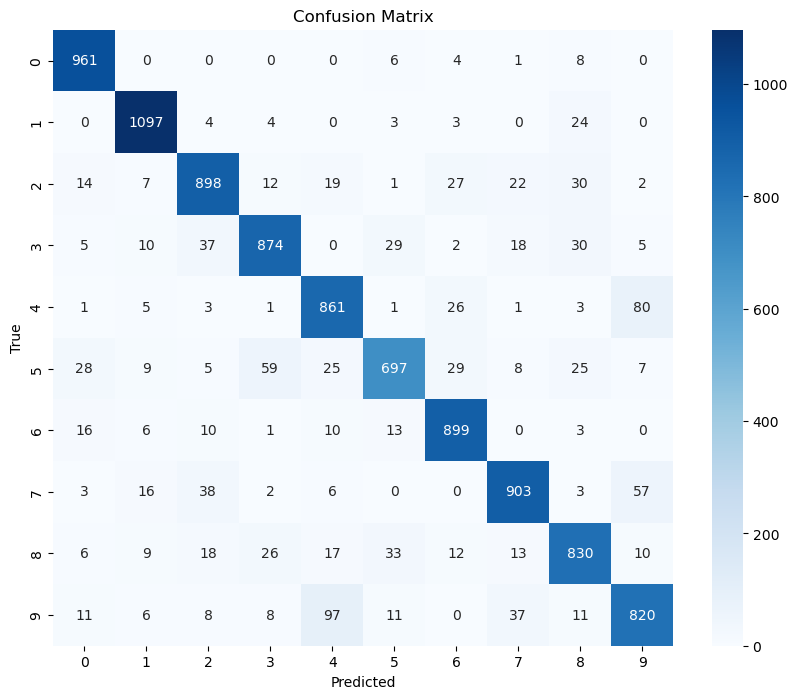


Примеры ошибок классификации:


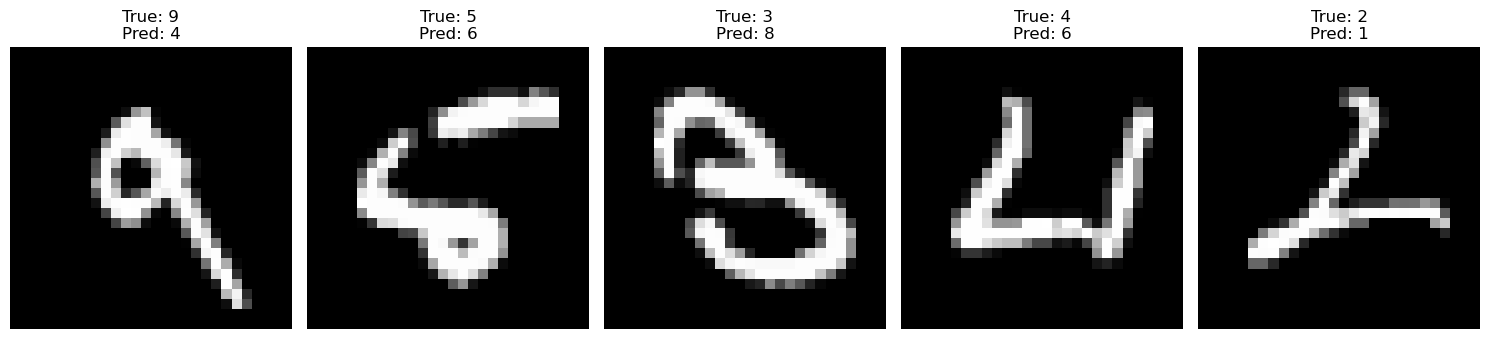


Самые частые ошибки:
9 → 4: 97 случаев
4 → 9: 80 случаев
5 → 3: 59 случаев
7 → 9: 57 случаев
7 → 2: 38 случаев
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.397349
Train Epoch: 2 [3200/60000 (5%)]	Loss: 0.346178
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.395613
Train Epoch: 2 [9600/60000 (16%)]	Loss: 0.389239
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.625865
Train Epoch: 2 [16000/60000 (27%)]	Loss: 0.599227
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.219433
Train Epoch: 2 [22400/60000 (37%)]	Loss: 0.351610
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.324227
Train Epoch: 2 [28800/60000 (48%)]	Loss: 0.407207
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.387141
Train Epoch: 2 [35200/60000 (59%)]	Loss: 0.462892
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.725214
Train Epoch: 2 [41600/60000 (69%)]	Loss: 0.275091
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.188113
Train Epoch: 2 [48000/60000 (80%)]	Loss: 0.522937
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.320104
Train Epoch: 2 [54400/60000 (91%)]	Loss: 0.3636

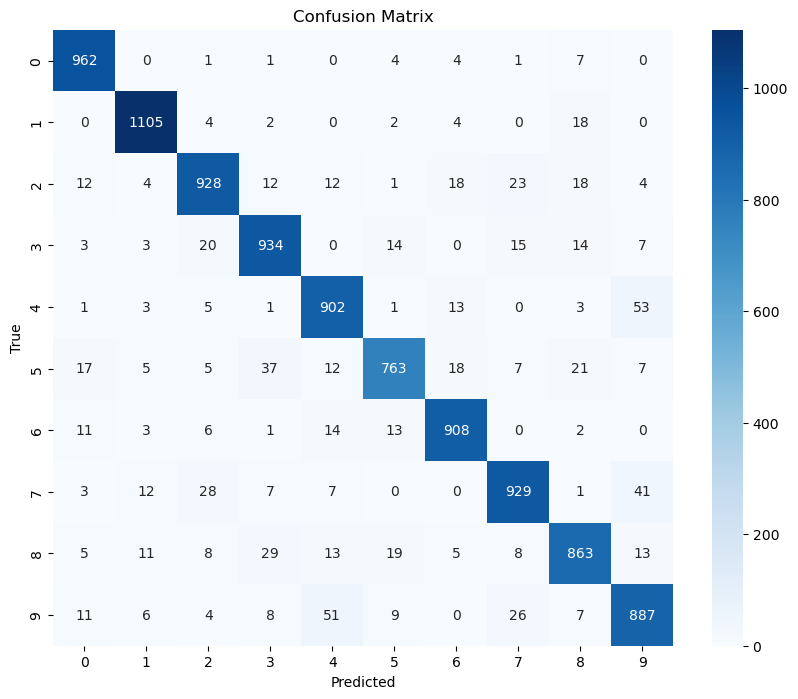


Примеры ошибок классификации:


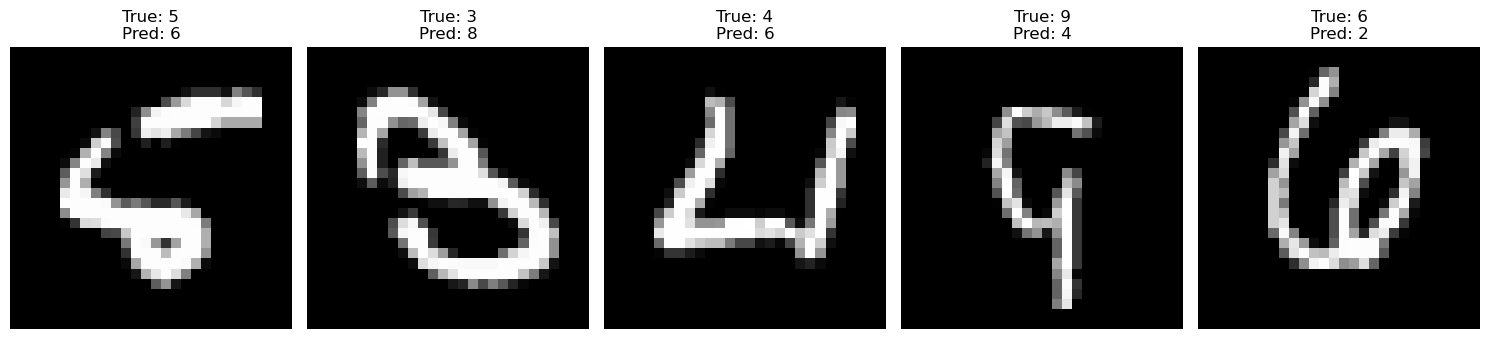


Самые частые ошибки:
4 → 9: 53 случаев
9 → 4: 51 случаев
7 → 9: 41 случаев
5 → 3: 37 случаев
8 → 3: 29 случаев
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.354069
Train Epoch: 3 [3200/60000 (5%)]	Loss: 0.161131
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.404913
Train Epoch: 3 [9600/60000 (16%)]	Loss: 0.382637
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.091194
Train Epoch: 3 [16000/60000 (27%)]	Loss: 0.165954
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.297473
Train Epoch: 3 [22400/60000 (37%)]	Loss: 0.159481
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.215497
Train Epoch: 3 [28800/60000 (48%)]	Loss: 0.200168
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.194240
Train Epoch: 3 [35200/60000 (59%)]	Loss: 0.251079
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.155306
Train Epoch: 3 [41600/60000 (69%)]	Loss: 0.265964
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.265327
Train Epoch: 3 [48000/60000 (80%)]	Loss: 0.427969
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.059352
Train Epoch: 3 [54400/60000 (91%)]	Loss: 0.1652

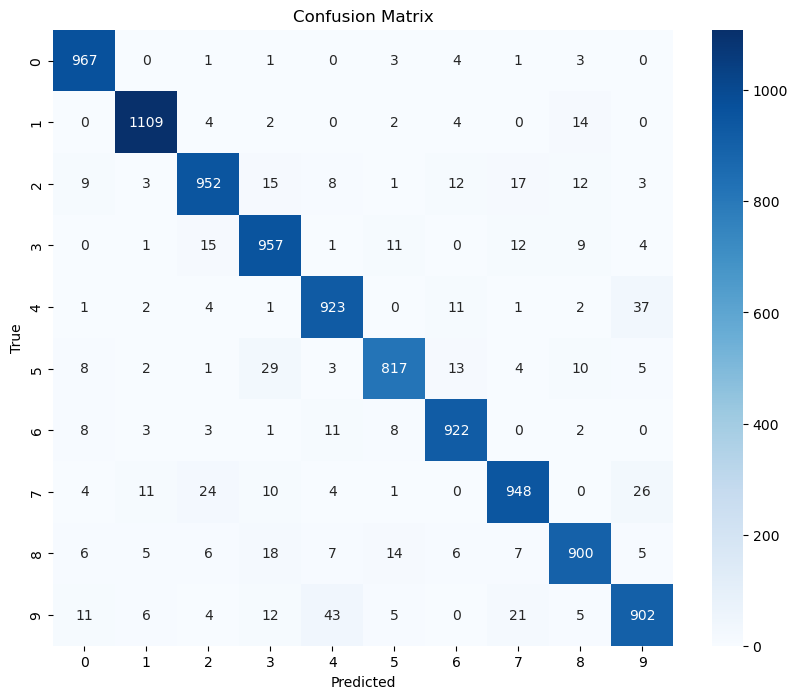


Примеры ошибок классификации:


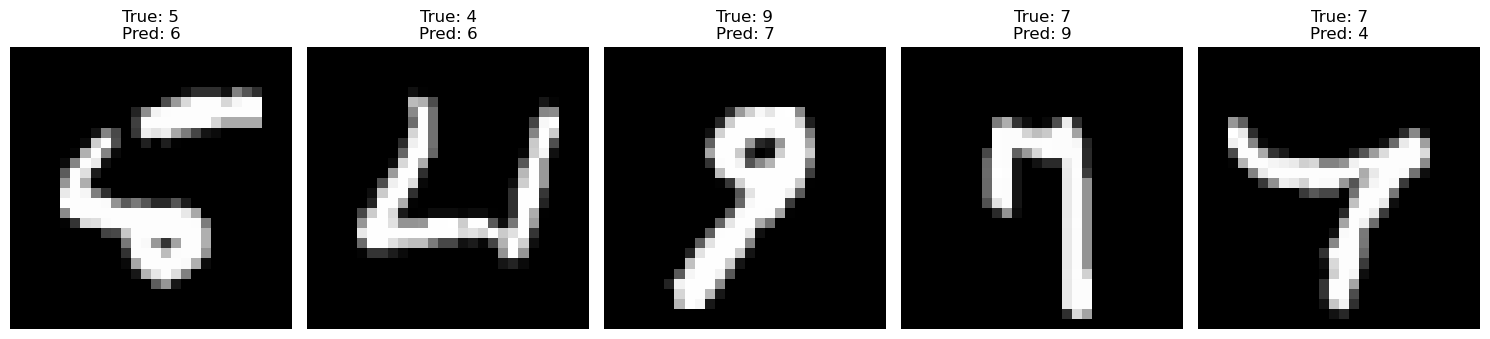


Самые частые ошибки:
9 → 4: 43 случаев
4 → 9: 37 случаев
5 → 3: 29 случаев
7 → 9: 26 случаев
7 → 2: 24 случаев
Train Epoch: 4 [0/60000 (0%)]	Loss: 0.094274
Train Epoch: 4 [3200/60000 (5%)]	Loss: 0.321313
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.143726
Train Epoch: 4 [9600/60000 (16%)]	Loss: 0.260929
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.349306
Train Epoch: 4 [16000/60000 (27%)]	Loss: 0.091820
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.170624
Train Epoch: 4 [22400/60000 (37%)]	Loss: 0.088810
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.292392
Train Epoch: 4 [28800/60000 (48%)]	Loss: 0.544275
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.146105
Train Epoch: 4 [35200/60000 (59%)]	Loss: 0.344562
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.202475
Train Epoch: 4 [41600/60000 (69%)]	Loss: 0.067729
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.275397
Train Epoch: 4 [48000/60000 (80%)]	Loss: 0.076557
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.293743
Train Epoch: 4 [54400/60000 (91%)]	Loss: 0.0870

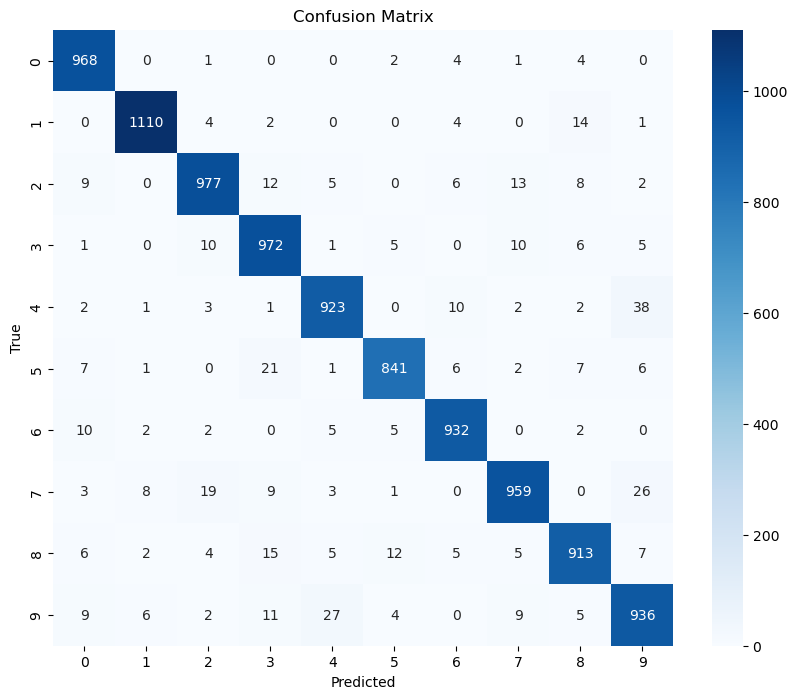


Примеры ошибок классификации:


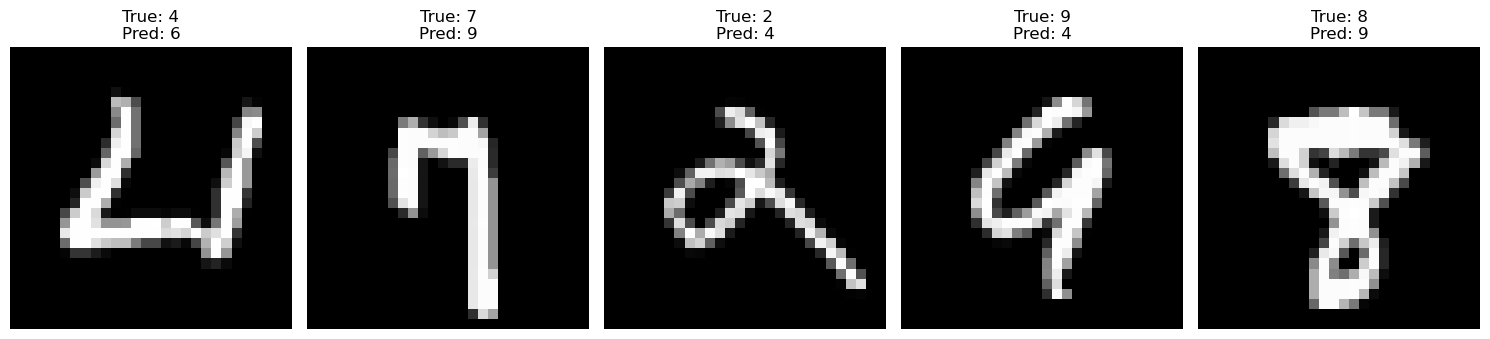


Самые частые ошибки:
4 → 9: 38 случаев
9 → 4: 27 случаев
7 → 9: 26 случаев
5 → 3: 21 случаев
7 → 2: 19 случаев
Train Epoch: 5 [0/60000 (0%)]	Loss: 0.193447
Train Epoch: 5 [3200/60000 (5%)]	Loss: 0.159867
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.197511
Train Epoch: 5 [9600/60000 (16%)]	Loss: 0.081657
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.107157
Train Epoch: 5 [16000/60000 (27%)]	Loss: 0.240247
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.069445
Train Epoch: 5 [22400/60000 (37%)]	Loss: 0.072779
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.036725
Train Epoch: 5 [28800/60000 (48%)]	Loss: 0.080929
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.096710
Train Epoch: 5 [35200/60000 (59%)]	Loss: 0.268778
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.101981
Train Epoch: 5 [41600/60000 (69%)]	Loss: 0.085431
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.192395
Train Epoch: 5 [48000/60000 (80%)]	Loss: 0.087353
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.391008
Train Epoch: 5 [54400/60000 (91%)]	Loss: 0.1077

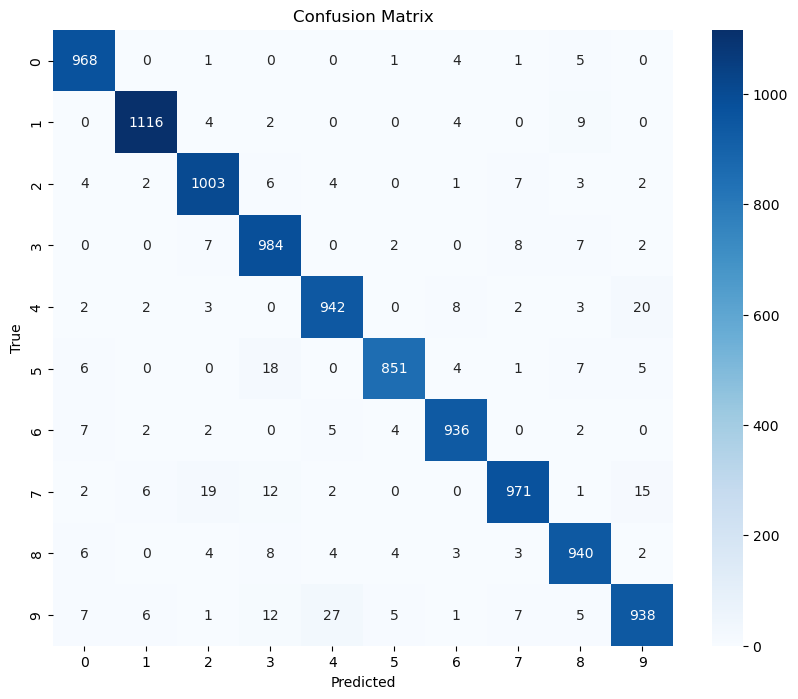


Примеры ошибок классификации:


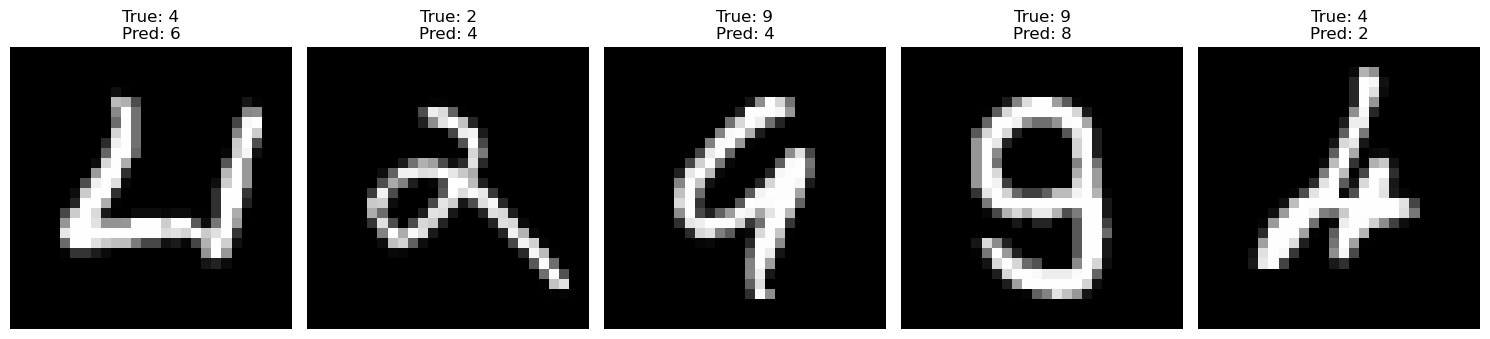


Самые частые ошибки:
9 → 4: 27 случаев
4 → 9: 20 случаев
7 → 2: 19 случаев
5 → 3: 18 случаев
7 → 9: 15 случаев
Train Epoch: 6 [0/60000 (0%)]	Loss: 0.043668
Train Epoch: 6 [3200/60000 (5%)]	Loss: 0.183258
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.127432
Train Epoch: 6 [9600/60000 (16%)]	Loss: 0.102357
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.420359
Train Epoch: 6 [16000/60000 (27%)]	Loss: 0.071225
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.123442
Train Epoch: 6 [22400/60000 (37%)]	Loss: 0.090977
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.308630
Train Epoch: 6 [28800/60000 (48%)]	Loss: 0.176412
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.192870
Train Epoch: 6 [35200/60000 (59%)]	Loss: 0.112122
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.087532
Train Epoch: 6 [41600/60000 (69%)]	Loss: 0.155893
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.189004
Train Epoch: 6 [48000/60000 (80%)]	Loss: 0.025127
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.134399
Train Epoch: 6 [54400/60000 (91%)]	Loss: 0.2551

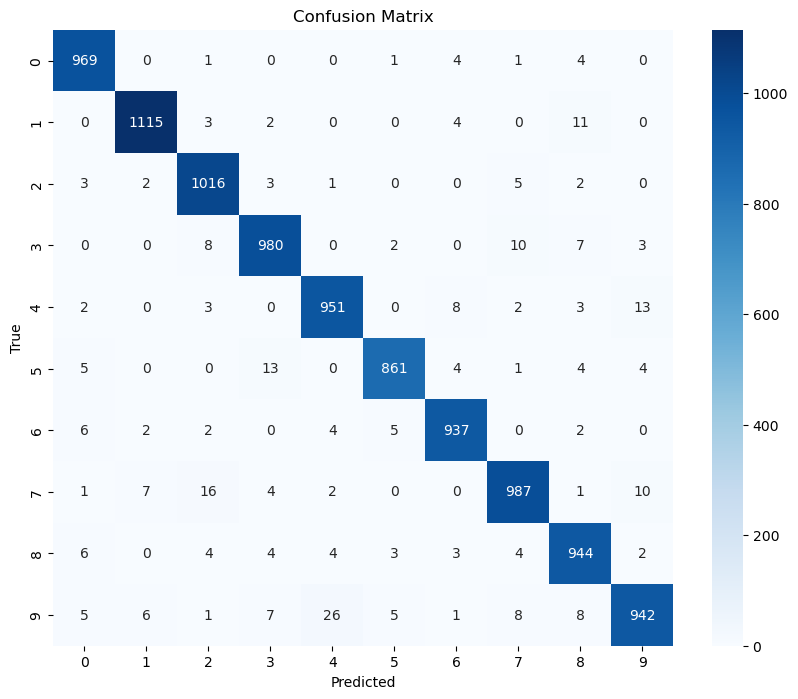


Примеры ошибок классификации:


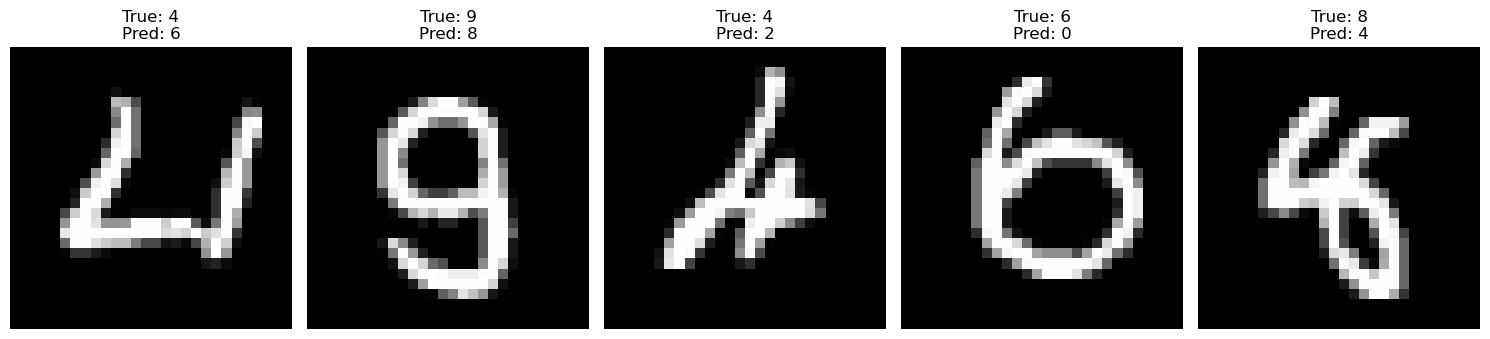


Самые частые ошибки:
9 → 4: 26 случаев
7 → 2: 16 случаев
4 → 9: 13 случаев
5 → 3: 13 случаев
1 → 8: 11 случаев
Train Epoch: 7 [0/60000 (0%)]	Loss: 0.198164
Train Epoch: 7 [3200/60000 (5%)]	Loss: 0.109184
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.312582
Train Epoch: 7 [9600/60000 (16%)]	Loss: 0.060304
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.195114
Train Epoch: 7 [16000/60000 (27%)]	Loss: 0.556858
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.147086
Train Epoch: 7 [22400/60000 (37%)]	Loss: 0.107737
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.070040
Train Epoch: 7 [28800/60000 (48%)]	Loss: 0.150692
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.083952
Train Epoch: 7 [35200/60000 (59%)]	Loss: 0.268402
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.059557
Train Epoch: 7 [41600/60000 (69%)]	Loss: 0.157830
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.012654
Train Epoch: 7 [48000/60000 (80%)]	Loss: 0.162982
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.060270
Train Epoch: 7 [54400/60000 (91%)]	Loss: 0.1206

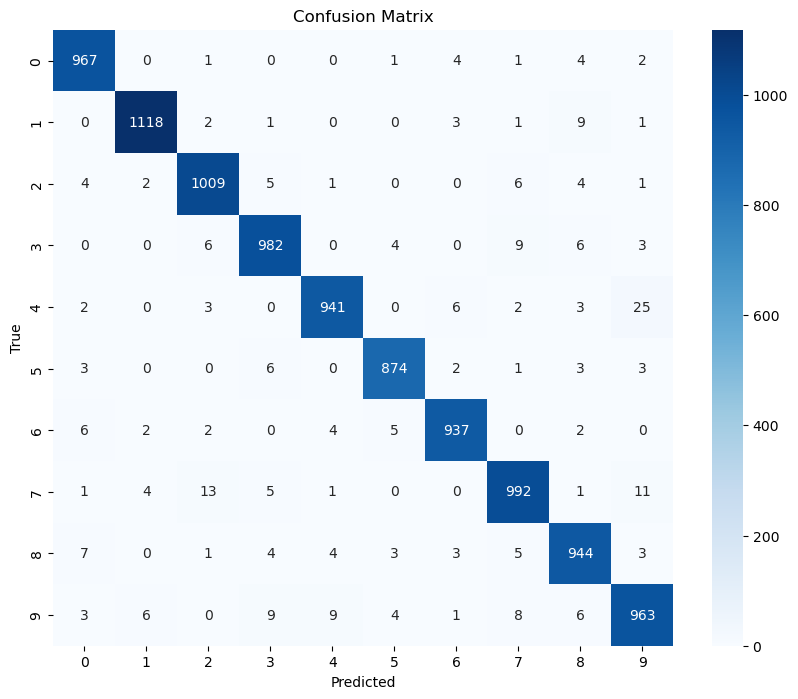


Примеры ошибок классификации:


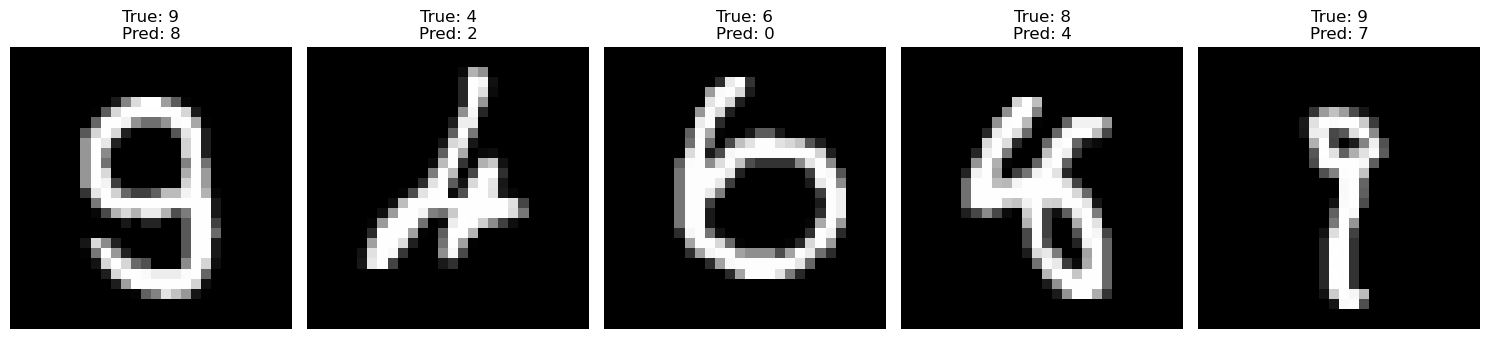


Самые частые ошибки:
4 → 9: 25 случаев
7 → 2: 13 случаев
7 → 9: 11 случаев
1 → 8: 9 случаев
3 → 7: 9 случаев
Train Epoch: 8 [0/60000 (0%)]	Loss: 0.021283
Train Epoch: 8 [3200/60000 (5%)]	Loss: 0.128010
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.031140
Train Epoch: 8 [9600/60000 (16%)]	Loss: 0.055763
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.046987
Train Epoch: 8 [16000/60000 (27%)]	Loss: 0.079049
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.019884
Train Epoch: 8 [22400/60000 (37%)]	Loss: 0.205200
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.111829
Train Epoch: 8 [28800/60000 (48%)]	Loss: 0.145765
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.034562
Train Epoch: 8 [35200/60000 (59%)]	Loss: 0.053493
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.157015
Train Epoch: 8 [41600/60000 (69%)]	Loss: 0.054825
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.035160
Train Epoch: 8 [48000/60000 (80%)]	Loss: 0.055175
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.198375
Train Epoch: 8 [54400/60000 (91%)]	Loss: 0.012028

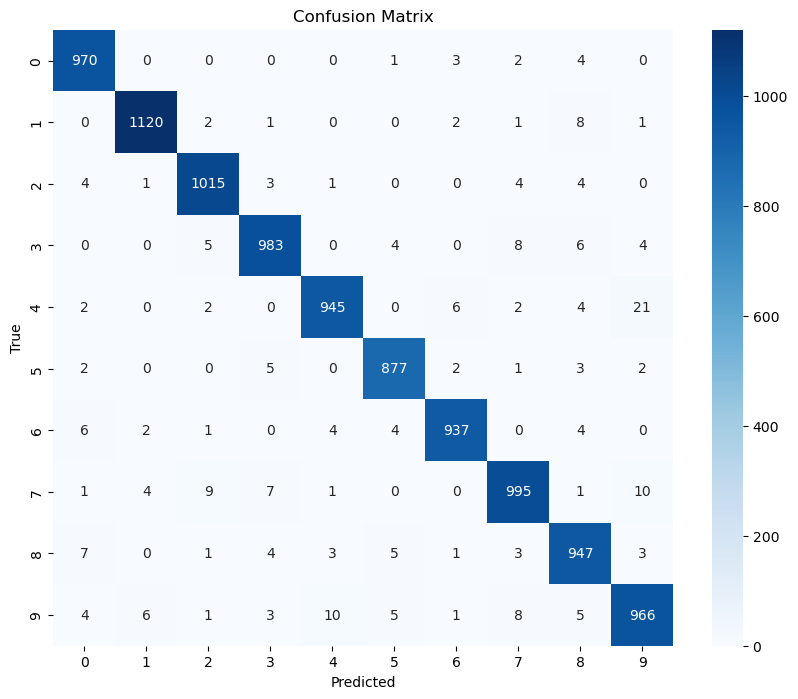


Примеры ошибок классификации:


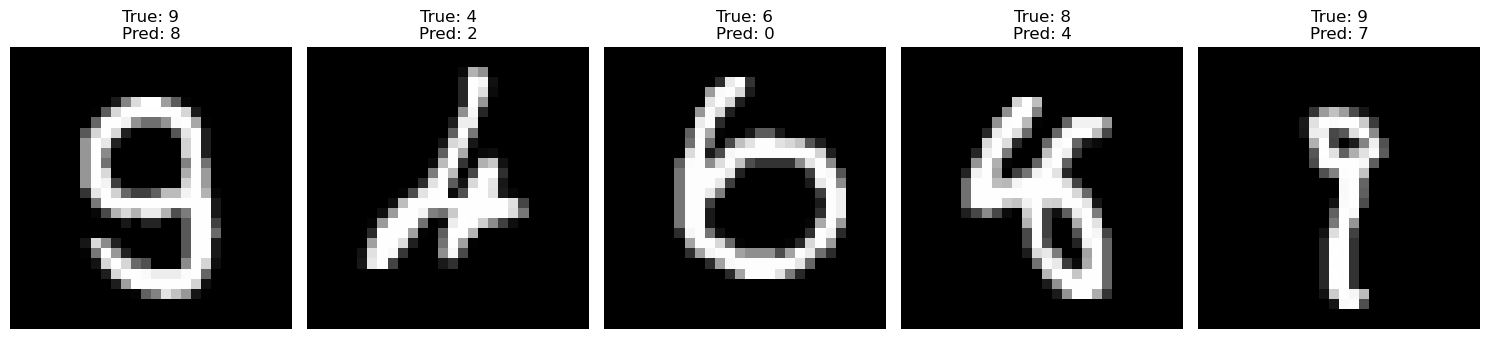


Самые частые ошибки:
4 → 9: 21 случаев
7 → 9: 10 случаев
9 → 4: 10 случаев
7 → 2: 9 случаев
9 → 7: 8 случаев
Train Epoch: 9 [0/60000 (0%)]	Loss: 0.220569
Train Epoch: 9 [3200/60000 (5%)]	Loss: 0.164693
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.045566
Train Epoch: 9 [9600/60000 (16%)]	Loss: 0.051466
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.038706
Train Epoch: 9 [16000/60000 (27%)]	Loss: 0.067967
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.207349
Train Epoch: 9 [22400/60000 (37%)]	Loss: 0.053631
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.235648
Train Epoch: 9 [28800/60000 (48%)]	Loss: 0.022450
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.156864
Train Epoch: 9 [35200/60000 (59%)]	Loss: 0.086537
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.047807
Train Epoch: 9 [41600/60000 (69%)]	Loss: 0.042023
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.062826
Train Epoch: 9 [48000/60000 (80%)]	Loss: 0.164879
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.382818
Train Epoch: 9 [54400/60000 (91%)]	Loss: 0.041110

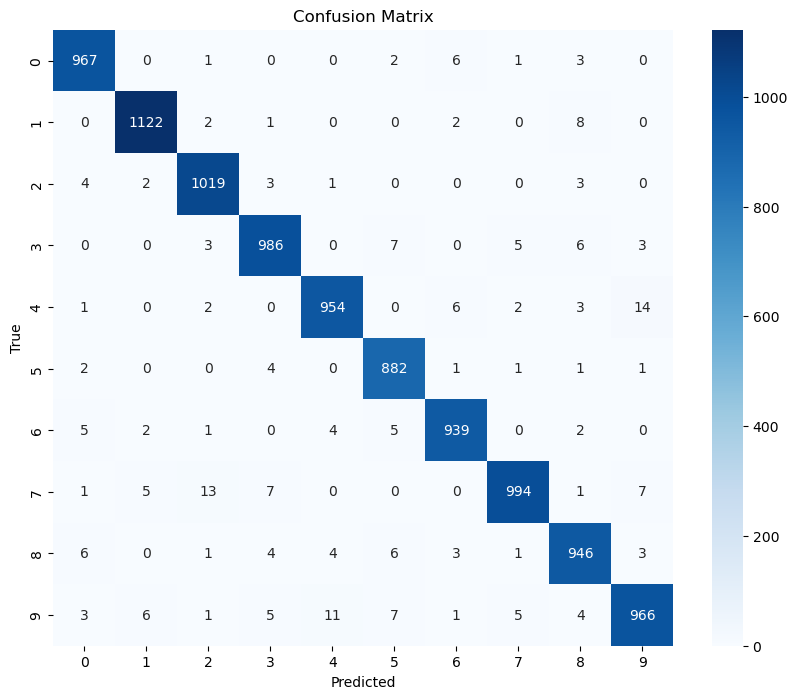


Примеры ошибок классификации:


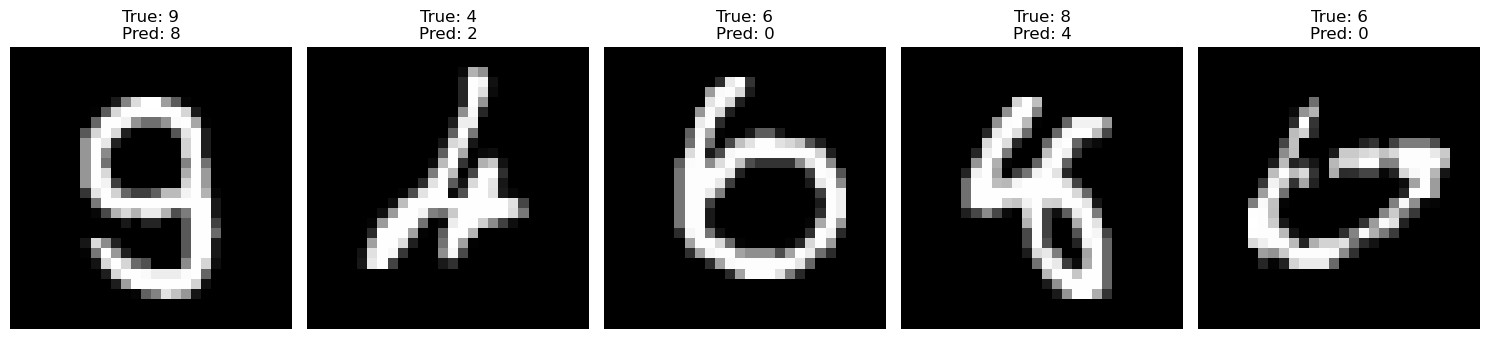


Самые частые ошибки:
4 → 9: 14 случаев
7 → 2: 13 случаев
9 → 4: 11 случаев
1 → 8: 8 случаев
3 → 5: 7 случаев
Train Epoch: 10 [0/60000 (0%)]	Loss: 0.084911
Train Epoch: 10 [3200/60000 (5%)]	Loss: 0.278088
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.073902
Train Epoch: 10 [9600/60000 (16%)]	Loss: 0.220076
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.037035
Train Epoch: 10 [16000/60000 (27%)]	Loss: 0.064476
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.128197
Train Epoch: 10 [22400/60000 (37%)]	Loss: 0.014139
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.041447
Train Epoch: 10 [28800/60000 (48%)]	Loss: 0.085758
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.045641
Train Epoch: 10 [35200/60000 (59%)]	Loss: 0.089645
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.007797
Train Epoch: 10 [41600/60000 (69%)]	Loss: 0.018129
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.049869
Train Epoch: 10 [48000/60000 (80%)]	Loss: 0.158026
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.134334
Train Epoch: 10 [54400/60000 (91

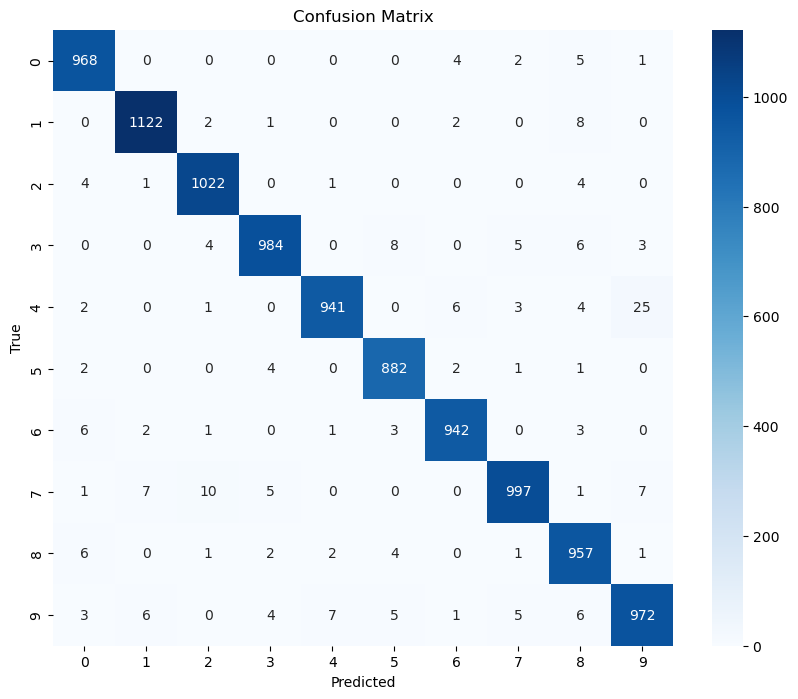


Примеры ошибок классификации:


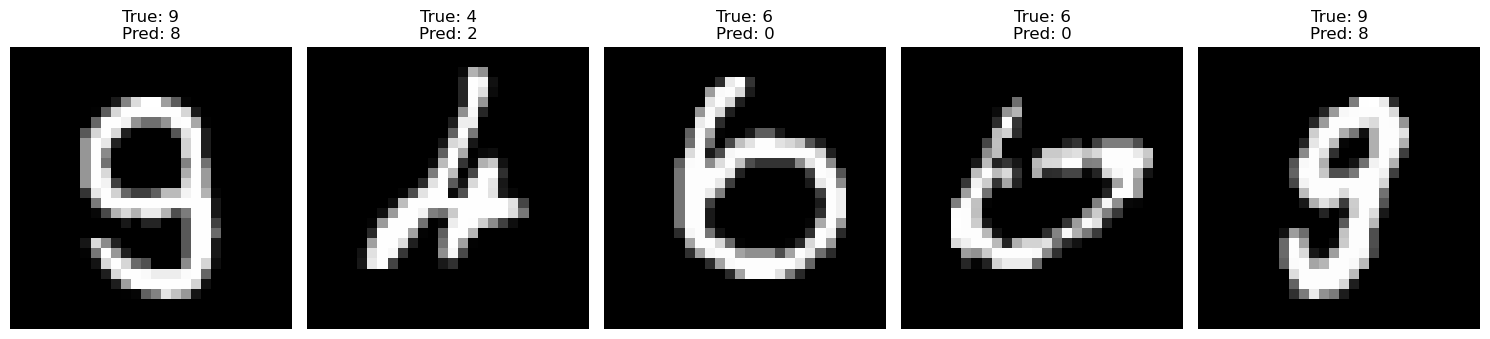


Самые частые ошибки:
4 → 9: 25 случаев
7 → 2: 10 случаев
3 → 5: 8 случаев
1 → 8: 8 случаев
7 → 1: 7 случаев


In [91]:
if __name__ == '__main__':
    main()